Sample rate: 16000 Hz
Duración: 4.87 s
Configuración 1: sin traslape | Ventana=20 ms | FFT=512
  Ventana: 20 ms (320 muestras)
  Traslape: 20 ms (320 muestras)
  FFT: 512
  Shape: (1, 257, 244)



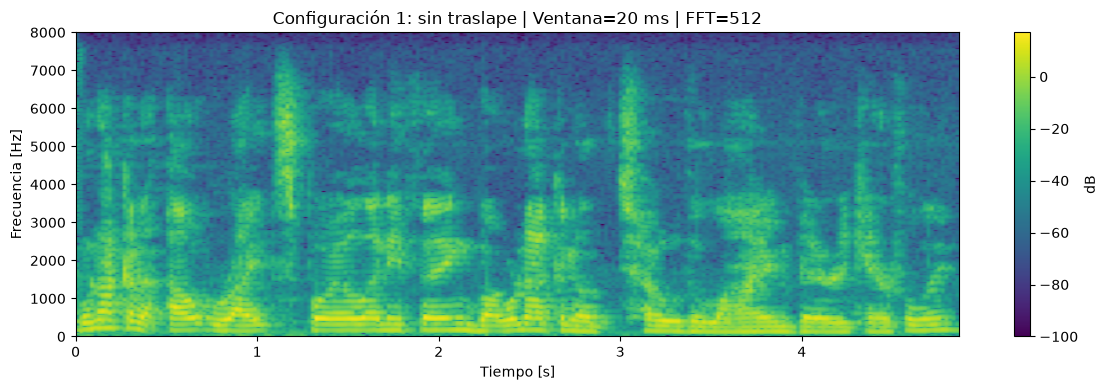

Configuración 2: sin traslape | Ventana=25 ms | FFT=512
  Ventana: 25 ms (400 muestras)
  Traslape: 25 ms (400 muestras)
  FFT: 512
  Shape: (1, 257, 195)



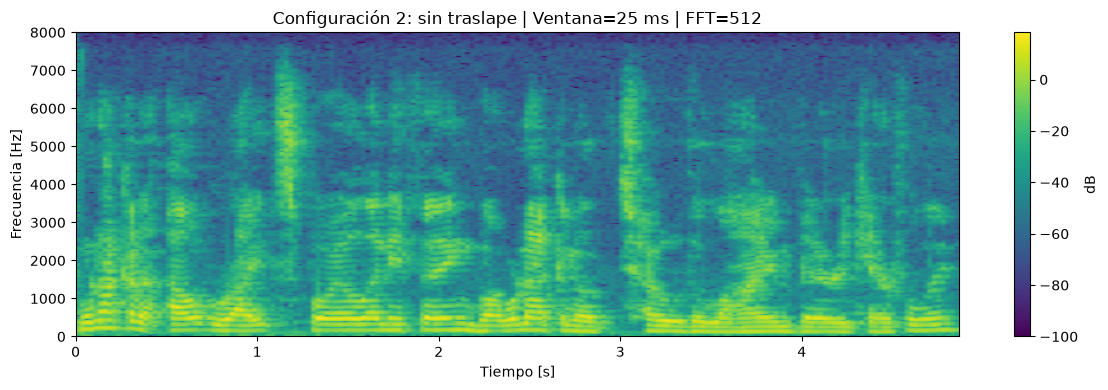

Configuración 3: sin traslape | Ventana=30 ms | FFT=512
  Ventana: 30 ms (480 muestras)
  Traslape: 30 ms (480 muestras)
  FFT: 512
  Shape: (1, 257, 163)



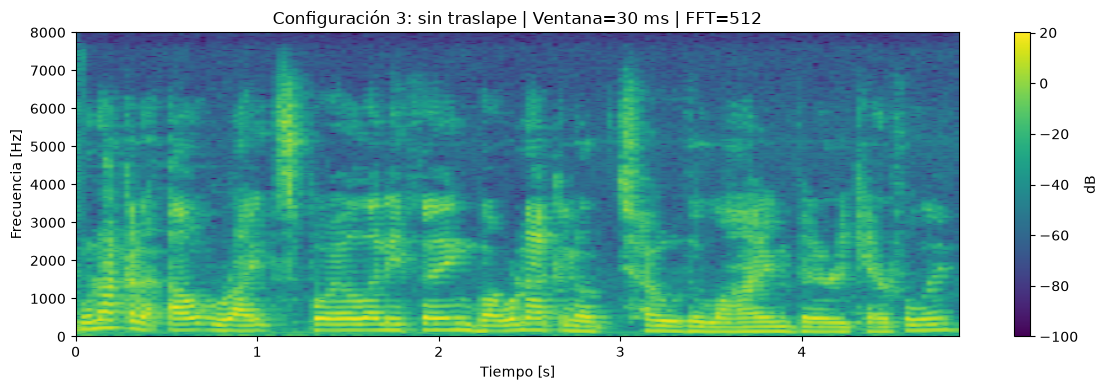

Configuración 4: 50% traslape | Ventana=20 ms | FFT=512
  Ventana: 20 ms (320 muestras)
  Traslape: 10 ms (160 muestras)
  FFT: 512
  Shape: (1, 257, 487)



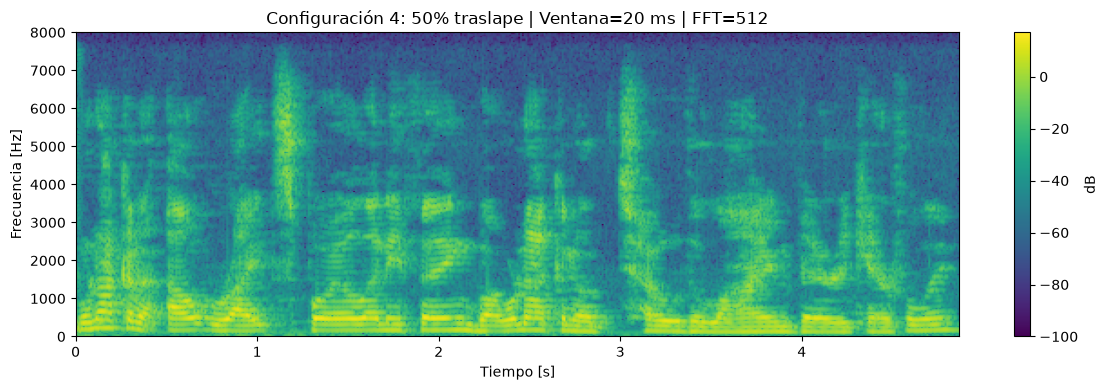

Configuración 5: 50% traslape | Ventana=25 ms | FFT=512
  Ventana: 25 ms (400 muestras)
  Traslape: 12.5 ms (200 muestras)
  FFT: 512
  Shape: (1, 257, 390)



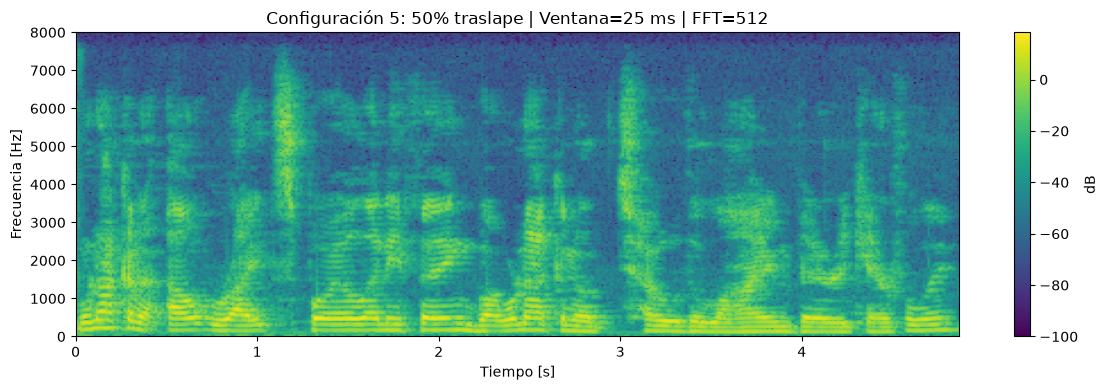

Configuración 6: 50% traslape | Ventana=30 ms | FFT=512
  Ventana: 30 ms (480 muestras)
  Traslape: 15 ms (240 muestras)
  FFT: 512
  Shape: (1, 257, 325)



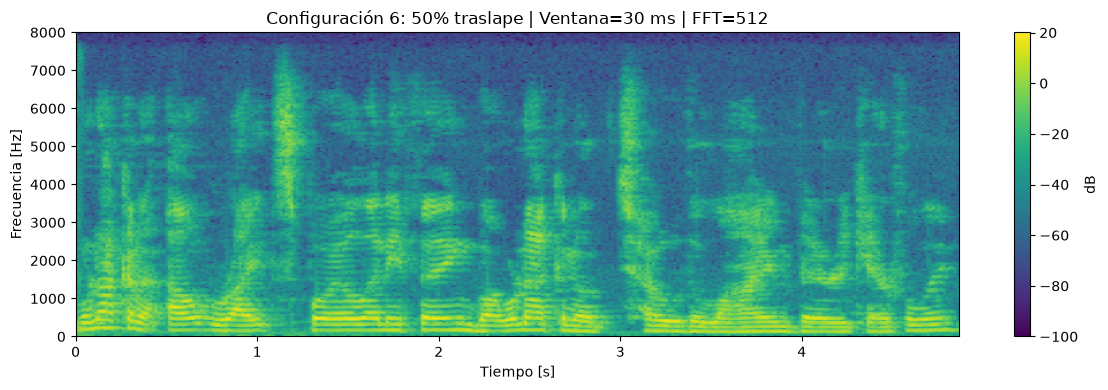

In [19]:
import torch
import torchaudio
import matplotlib.pyplot as plt

audio_path = "Emociones\\Podcast\\train\\0.wav"

waveform, sample_rate = torchaudio.load(audio_path)
waveform = waveform[0]

print(f"Sample rate: {sample_rate} Hz")
print(f"Duración: {len(waveform) / sample_rate:.2f} s")


def plot_spectrogram(
    waveform,
    sample_rate,
    window_ms,
    traslape_ms,
    n_fft,
    title=""
):
    win_length = int(sample_rate * window_ms / 1000)
    traslape_length = int(sample_rate * traslape_ms / 1000)

    if win_length > n_fft:
        print(
            f"Configuración inválida: "
            f"win_length={win_length} > n_fft={n_fft}"
        )
        return

    transform = torchaudio.transforms.Spectrogram(
        n_fft=n_fft,
        win_length=win_length,
        hop_length=traslape_length,
        power=2
    )

    spectrogram = transform(waveform.unsqueeze(0))

    db_transform = torchaudio.transforms.AmplitudeToDB()
    spectrogram_db = db_transform(spectrogram)

    print(
        f"{title}\n"
        f"  Ventana: {window_ms} ms ({win_length} muestras)\n"
        f"  Traslape: {traslape_ms} ms ({traslape_length} muestras)\n"
        f"  FFT: {n_fft}\n"
        f"  Shape: {tuple(spectrogram.shape)}\n"
    )

    plt.figure(figsize=(12, 4))

    plt.imshow(
        spectrogram_db[0].numpy(),
        aspect="auto",
        origin="lower",
        extent=[
            0,
            len(waveform) / sample_rate,
            0,
            sample_rate / 2
        ]
    )

    plt.xlabel("Tiempo [s]")
    plt.ylabel("Frecuencia [Hz]")
    plt.title(title)
    plt.colorbar(label="dB")
    plt.tight_layout()
    plt.show()


configuraciones_sin_traslape = [
    (20, 20, 512),
    (25, 25, 512),
    (30, 30, 512)
]

for i, (window_ms, traslape_ms, n_fft) in enumerate(
    configuraciones_sin_traslape, 1
):
    plot_spectrogram(
        waveform,
        sample_rate,
        window_ms,
        traslape_ms,
        n_fft,
        title=f"Configuración {i}: sin traslape | "
              f"Ventana={window_ms} ms | FFT={n_fft}"
    )


# traslape

configuraciones_traslape = [
    (20, 10, 512),
    (25, 12.5, 512),
    (30, 15, 512)
]

for i, (window_ms, traslape_ms, n_fft) in enumerate(
    configuraciones_traslape, 4
):
    plot_spectrogram(
        waveform,
        sample_rate,
        window_ms,
        traslape_ms,
        n_fft,
        title=f"Configuración {i}: 50% traslape | "
              f"Ventana={window_ms} ms | FFT={n_fft}"
    )



Configuración 7: ventana=25 ms | 50% traslape | FFT=512
  Ventana: 25 ms (400 muestras)
  Traslape: 12.5 ms (200 muestras)
  FFT: 512
  Shape: (1, 257, 390)



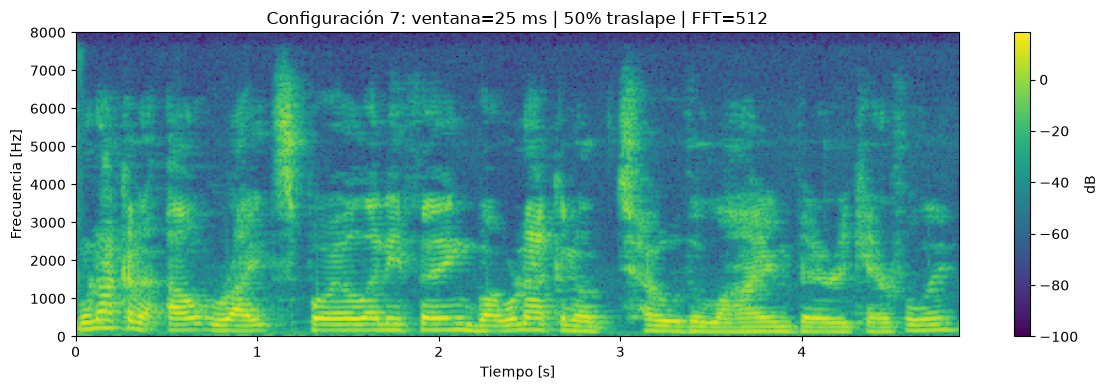

Configuración 8: ventana=25 ms | 50% traslape | FFT=1024
  Ventana: 25 ms (400 muestras)
  Traslape: 12.5 ms (200 muestras)
  FFT: 1024
  Shape: (1, 513, 390)



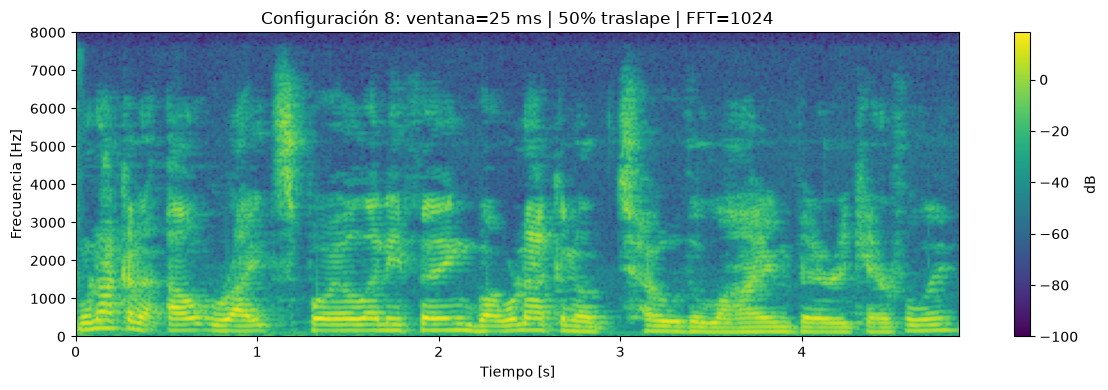

Configuración 9: ventana=25 ms | 50% traslape | FFT=2048
  Ventana: 25 ms (400 muestras)
  Traslape: 12.5 ms (200 muestras)
  FFT: 2048
  Shape: (1, 1025, 390)



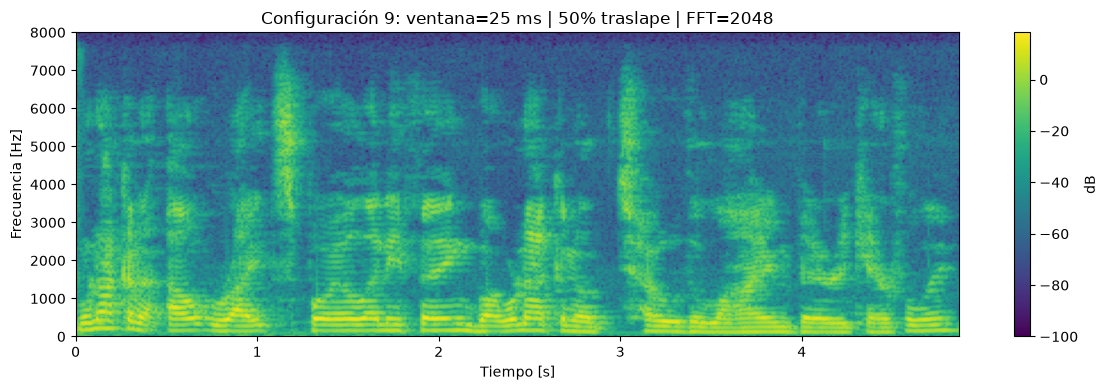

In [20]:
# tamanos ffts

configuraciones_fft = [
    (25, 12.5, 512),
    (25, 12.5, 1024),
    (25, 12.5, 2048)
]

for i, (window_ms, traslape_ms, n_fft) in enumerate(
    configuraciones_fft, 7
):
    plot_spectrogram(
        waveform,
        sample_rate,
        window_ms,
        traslape_ms,
        n_fft,
        title=f"Configuración {i}: ventana={window_ms} ms | "
              f"50% traslape | FFT={n_fft}"
    )